# Linear Variational Method - Quantum Harmonic Oscillator (QHO)

In this notebook, We will solve using numeric (and symbolic) calculations the Quantum Harmonic Oscillator. We will approximate the energy eigenstates and wavefunctions by using a trial wave function (the variational trial function) that is a linear combination of a basis (specifically, we will use the eigenfunctions of the infinite square well of length L (symmetric about the origin)). This basis will not be complete since we will cut it and not use the infinite set that will make it complete (because the computer has finite resources).

The Hamiltonian is given by:


In [1]:
# --- Imports ---

# 1. Jupyter Magic Commands (Forces notebook to reload external .py files)
%load_ext autoreload
%autoreload 2

# 1. Symbolic Mathematics (Analytical Derivations & Units)
import sympy as sp
from IPython.display import display, Math # For rendering LaTeX beautifully in Jupyter

# 2. Numerical Arrays and Matrices
import numpy as np

# 3. Scientific Computing (Integration and Eigenvalue Solvers)
from scipy.integrate import quad
from scipy.linalg import eigh

# 4. Visualization (Convergence and Error Graphs)
import matplotlib.pyplot as plt

# 5. Numerical integration methods (custom implementations)
from numerical_integration_methods import (
    integral_solve_using_trapezoidal_rule, 
    integral_solve_using_romberg_method, 
    integral_solve_using_simpsons_rule, 
    scipy_quad_wrapper,
    INTEGRATION_DISPATCH
)

import config as cfg

In [2]:
# --- Variational Parameters ---
L = 10.0      # The domain size of the infinite well [-L/2, L/2]
N_BASIS = 50  # The size of the basis (k = 1, 2, ..., N_BASIS)
N_STATES = 5  # How many low-lying energy levels to track (should be << N_BASIS)

In [3]:
def basis_function(x, n, L) -> float:
    """
    Evaluates the n-th infinite square well basis function at position x.

    Parameters
    ----------
    x : float
        Position where the function is evaluated.
    n : int
        Basis index.
    L : float
        Width of the well.

    Returns
    -------
    float
        Value of the basis function at x.
    """
    normalization = np.sqrt(2.0 / L)
    argument = (n * np.pi * (x + L / 2.0)) / L
    
    return normalization * np.sin(argument)

def integrand_V(x, n, m, L, mass, omega) -> float:
    """
    The potential energy integrand: chi_n(x) * V(x) * chi_m(x).
    """
    chi_n = basis_function(x, n, L)
    chi_m = basis_function(x, m, L)
    
    V_x = 0.5 * mass * ((omega * x)**2)  # QHO Potential: 1/2 * mass * omega^2 * x^2
    
    return chi_n * V_x * chi_m

In [4]:
def build_hamiltonian_matrix(N_BASIS, L, mass, omega, integration_method='trapezoidal', N_GRID=1000):
    """Builds the N_BASIS x N_BASIS Hamiltonian matrix
    
    Parameters
    ----------
    N_BASIS : int
        The size of the basis (k = 1, 2, ..., N_BASIS)
    L : float
        The domain size of the infinite well [-L/2, L/2]
    mass : float
        The mass of the particle
    omega : float
        The angular frequency of the harmonic oscillator
    integration_method : str, optional
        The numerical integration method to use (default is 'trapezoidal')
    N_GRID : int, optional
        The number of grid points for numerical integration (default is 1000)

    Returns
    -------
    np.ndarray
        The N_BASIS x N_BASIS Hamiltonian matrix
    """
    
    H = np.zeros((N_BASIS, N_BASIS))
    
    # Hamiltonian is hermitian, so H_i,j = H_j,i*. We only need to calculate N_BASIS + (N_BASIS - 1) + (N_BASIS - 2) + ... + 1 = N_BASIS * (N_BASIS + 1) / 2 unique elements. The rest can be filled in by symmetry.
    # H = T + V, where T is the kinetic energy term and V is the potential energy term.
    for i in range(N_BASIS):
        for j in range(i, N_BASIS):

            # shift indices to match basis functions (important!)
            n = i + 1
            m = j + 1

            # --- Kinetic Energy (Exact analytical result) ---
            T = 0.0
            # Using T = (hbar^2 * k^2) / 2m
            if n == m:
                k = (n * np.pi) / L
                T = ((cfg.HBAR * k)**2) / (2.0 * mass)

            # --- Potential Energy (Numerical Integration) ---
            V = 0.0

            if integration_method == 'analytical':
                pass #TODO
                # Use the analytical formula derived using SymPy
                # V = calculate_V_analytical(n, m, L) #TODO

            elif integration_method in INTEGRATION_DISPATCH:
                integration_method_func = INTEGRATION_DISPATCH[integration_method]

                V = integration_method_func(integrand_V, -L/2, L/2, N_GRID, n, m, L, mass, omega)

            else:
                raise ValueError("Invalid integration method selected!")
            
            H[i, j] = T + V
            if i != j:
                H[j, i] = H[i, j]  # Fill in the symmetric element (base functions are real, so H is symmetric)
            
    return H
        
# Maybe calculate S matrix here for generality, but for the infinite square well, the basis functions are orthonormal, so S = I (identity matrix).

def solve_hamiltonian(H, N_STATES, eigen_method):
    """Diagonalizes the Hamiltonian and returns the lowest N_STATES."""
    # Solve secular equation, which is just the eigenvalue problem for the Hamiltonian matrix H.
    if eigen_method == 'scipy': # TODO: add parameters docstring and also use strategy pattern here as well.
        energies, wavefunctions = eigh(H)
    elif eigen_method == 'QR': # TODO: implement those methods!
        pass # energies, wavefunctions = custom_qr_algorithm(H)
    elif eigen_method == 'Jacobi':
        pass # energies, wavefunctions = custom_jacobi_iteration(H)
    else:
        raise ValueError(f"Invalid eigenvalue method: {eigen_method}")
        
    # Sort eigenvalues from lowest to highest
    sort_indices = np.argsort(energies)
    sorted_energies = energies[sort_indices]
    sorted_wavefunctions = wavefunctions[:, sort_indices]
    
    return sorted_energies[:N_STATES], sorted_wavefunctions[:, :N_STATES]

def calculate_qho_energies_and_states(L_val, N_BASIS_val, N_STATES_val):
    """Master pipeline: Builds the matrix and solves it for given parameters."""
    H_matrix = build_hamiltonian_matrix(
        N_BASIS=N_BASIS_val, 
        L=L_val, 
        mass=cfg.MASS, 
        omega=cfg.OMEGA, 
        integration_method=cfg.integration_method, 
        N_GRID=cfg.N_GRID
    )
    
    energies, states = solve_hamiltonian(
        H=H_matrix, 
        N_STATES=N_STATES_val, 
        eigen_method=cfg.eigenvalue_method
    )
    
    return energies, states

In [5]:
# # The exact theoretical energies (see derivation in the notebook TODO: add markdown derivation and also maybe if possible a link here to the derivation in the notebook)
# exact_energies = np.array([n + 0.5 for n in range(N_STATES)])

# # # the error between the computed energies and the exact energies
# errors = np.abs(energies[:N_STATES] - exact_energies)
# energies

In [6]:
# ==========================================
# SANITY CHECK: Single Run using Defaults
# ==========================================

print(f"Running Sanity Check with L={cfg.DEFAULT_L}, N_BASIS={cfg.DEFAULT_N_BASIS}")

# 1. Run the pipeline
test_energies, test_states = calculate_qho_energies_and_states(
    L_val=cfg.DEFAULT_L, 
    N_BASIS_val=cfg.DEFAULT_N_BASIS, 
    N_STATES_val=cfg.DEFAULT_N_STATES
)

# 2. Calculate the exact theoretical energies (E_n = n + 0.5)
exact_energies = np.array([n + 0.5 for n in range(cfg.DEFAULT_N_STATES)])

# 3. Calculate absolute error
errors = np.abs(test_energies - exact_energies)

# 4. Display Results
print("\nExact Energies:    ", exact_energies)
print("Computed Energies: ", test_energies)
print("Absolute Errors:   ", errors)

Running Sanity Check with L=30.0, N_BASIS=50

Exact Energies:     [0.5 1.5 2.5 3.5 4.5]
Computed Energies:  [0.5        1.5        2.5        3.50000003 4.5000009 ]
Absolute Errors:    [3.12516679e-12 5.90829607e-11 4.47804283e-09 2.82022494e-08
 8.99302024e-07]


In [7]:
# # ==========================================
# # EXPERIMENT 1: Error vs. N_BASIS (Fixed L)
# # ==========================================

# # Experimental Setup
# L_fixed = 30.0
# basis_sizes = np.arange(25, 81, 5) # Test N_BASIS from 25 to 80 in steps of 5
# tracked_states = 20                # Track the first 20 states for a clean graph

# exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
# errors_vs_N = []

# print(f"Sweeping N_BASIS from 25 to 80 with fixed L={L_fixed}...")

# for N in basis_sizes:
#     # We pass the experimental N directly into your math engine
#     calc_energies, _ = calculate_qho_energies_and_states(
#         L_val=L_fixed, 
#         N_BASIS_val=N, 
#         N_STATES_val=tracked_states
#     )
    
#     # Calculate the absolute error against the theoretical formula
#     error = np.abs(calc_energies - exact_energies)
#     errors_vs_N.append(error)

# # Convert list to a 2D NumPy array for easy plotting slicing
# errors_vs_N = np.array(errors_vs_N)

# # --- Matplotlib Plotting ---
# plt.figure(figsize=(10, 6))
# for state in range(tracked_states):
#     # Using a logarithmic y-axis to see the exponential convergence
#     plt.semilogy(basis_sizes, errors_vs_N[:, state], marker='o', label=f'State n={state}')

# plt.title(f'Convergence Error vs. Basis Size (Fixed L = {L_fixed})')
# plt.xlabel('Number of Basis Functions (N_BASIS)')
# plt.ylabel('Absolute Error (Log Scale)')
# plt.legend()
# plt.grid(True, which="both", ls="--", alpha=0.6)
# plt.show()

In [ ]:
# calc_energies

NameError: name 'calc_energies' is not defined

In [ ]:
errors

Sweeping L from 25.0 to 35.0 with fixed N_BASIS=60...


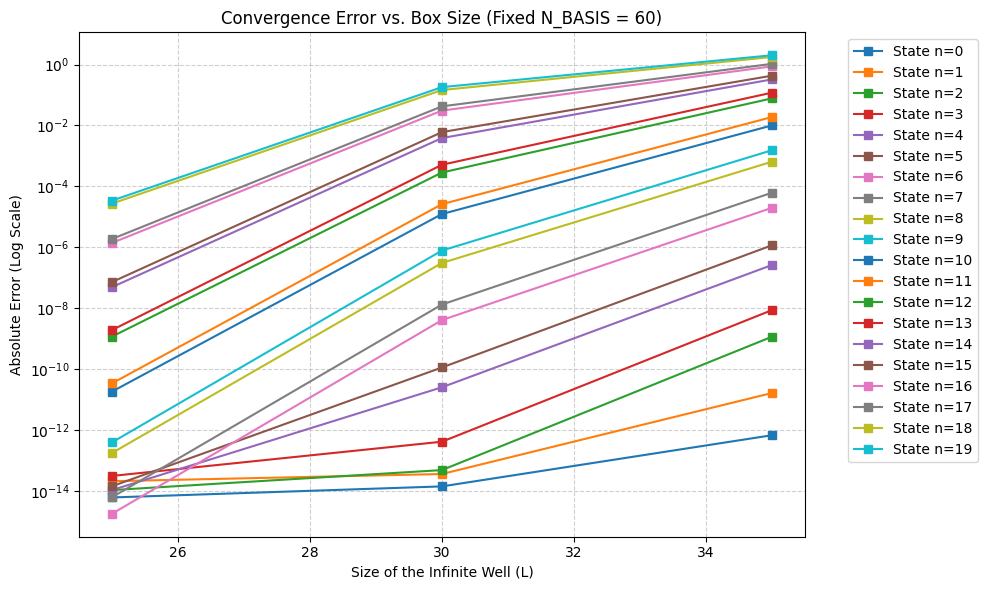

In [ ]:
# ==========================================
# EXPERIMENT 2: Error vs. Box Size L (Fixed N_BASIS)
# ==========================================

# Experimental Setup
N_fixed = 60  # Using the optimal basis size from your previous graphs
L_values = np.linspace(5.0, 35.0, 7) # Test 7 different box sizes from L=5 to L=35
tracked_states = 20

exact_energies = np.array([n + 0.5 for n in range(tracked_states)])
errors_vs_L = []

print(f"Sweeping L from 5.0 to 35.0 with fixed N_BASIS={N_fixed}...")

for L_val in L_values:
    # Pass the experimental L directly into your math engine
    calc_energies, _ = calculate_qho_energies_and_states(
        L_val=L_val, 
        N_BASIS_val=N_fixed, 
        N_STATES_val=tracked_states
    )
    error = np.abs(calc_energies - exact_energies)
    errors_vs_L.append(error)

errors_vs_L = np.array(errors_vs_L)

# --- Matplotlib Plotting ---
plt.figure(figsize=(10, 6))

# Plotting a subset of the 20 states to keep the graph readable
states_to_plot = [i for i in range(tracked_states)]

for state in states_to_plot:
    plt.semilogy(L_values, errors_vs_L[:, state], marker='s', label=f'State n={state}')

plt.title(f'Convergence Error vs. Box Size (Fixed N_BASIS = {N_fixed})')
plt.xlabel('Size of the Infinite Well (L)')
plt.ylabel('Absolute Error (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()